# Notebook 1: Data Preprocessing & EDA
## IDS Feature Selection & Hyperparameter Optimization
### COMP2024 — AI Methods Coursework

This notebook handles the crucial first steps:
1. Loading the raw CICIDS2017 dataset
2. Handling missing/infinite values and duplicates
3. Exploratory Data Analysis (EDA)
4. Label encoding
5. Stratified sampling, splitting, and normalization
6. Saving the cleaned dataset for modeling

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6)})
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = 'archive'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

SAMPLE_SIZE = 100_000
TEST_SIZE = 0.3

## 1. Load Raw Dataset

In [2]:
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and 'processed' not in f.lower()])
print(f'Loading {len(csv_files)} CSV files...')
dfs = []
for f in csv_files:
    df = pd.read_csv(os.path.join(DATA_DIR, f), low_memory=False)
    df.columns = df.columns.str.strip()
    dfs.append(df)
df_raw = pd.concat(dfs, ignore_index=True)
print(f'Total raw records: {len(df_raw):,} rows, {len(df_raw.columns)} columns')

Loading 8 CSV files...


Total raw records: 2,830,743 rows, 79 columns


## 2. Missing Values, Inf, and Duplicates

In [3]:
df_clean = df_raw.copy()

# Handle Infinities
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# Missing Values
missing = df_clean.isnull().sum()
print(f'Total Missing/Inf values found: {missing.sum():,}')
df_clean.dropna(inplace=True)

# Duplicates
before_dedup = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Removed {before_dedup - len(df_clean):,} duplicate records.')
print(f'Cleaned dataset: {len(df_clean):,} rows')

Total Missing/Inf values found: 5,734


Removed 307,078 duplicate records.
Cleaned dataset: 2,520,798 rows


## 3. Exploratory Data Analysis (EDA)

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


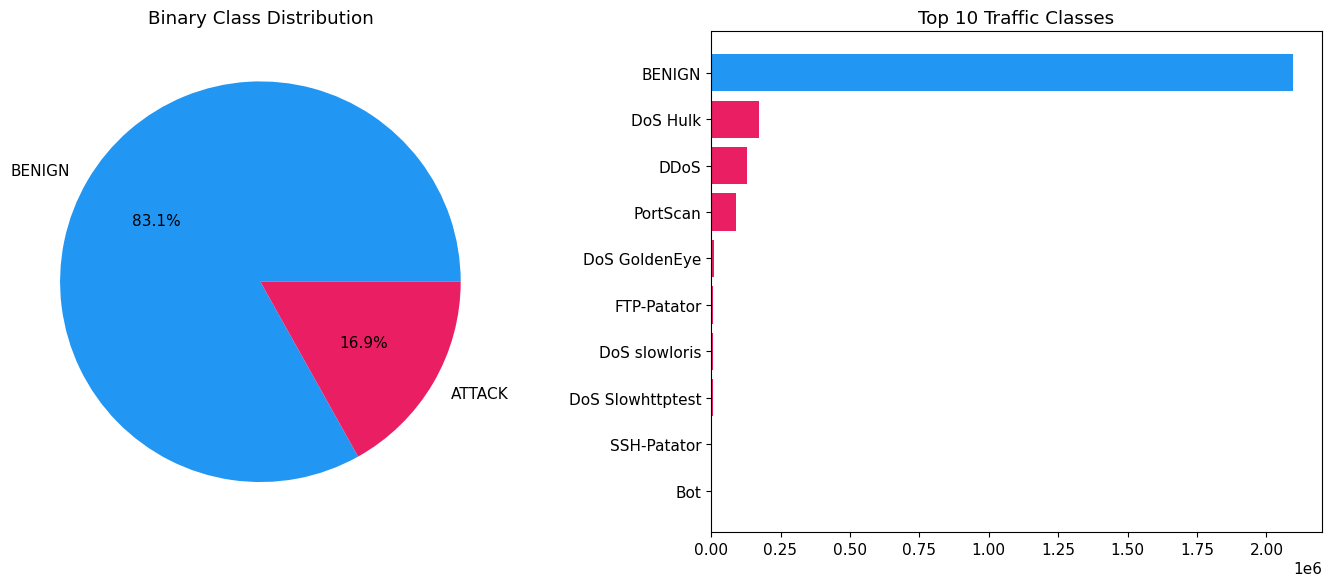

In [4]:
# Class Distribution
class_counts = df_clean['Label'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
benign_count = class_counts.get('BENIGN', 0)
attack_count = len(df_clean) - benign_count
axes[0].pie([benign_count, attack_count], labels=['BENIGN', 'ATTACK'], autopct='%1.1f%%', colors=['#2196F3', '#E91E63'])
axes[0].set_title('Binary Class Distribution')

top_classes = class_counts.head(10)
axes[1].barh(range(len(top_classes)), top_classes.values, color=['#2196F3'] + ['#E91E63']*(len(top_classes)-1))
axes[1].set_yticks(range(len(top_classes)))
axes[1].set_yticklabels(top_classes.index)
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Traffic Classes')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'))
plt.show()

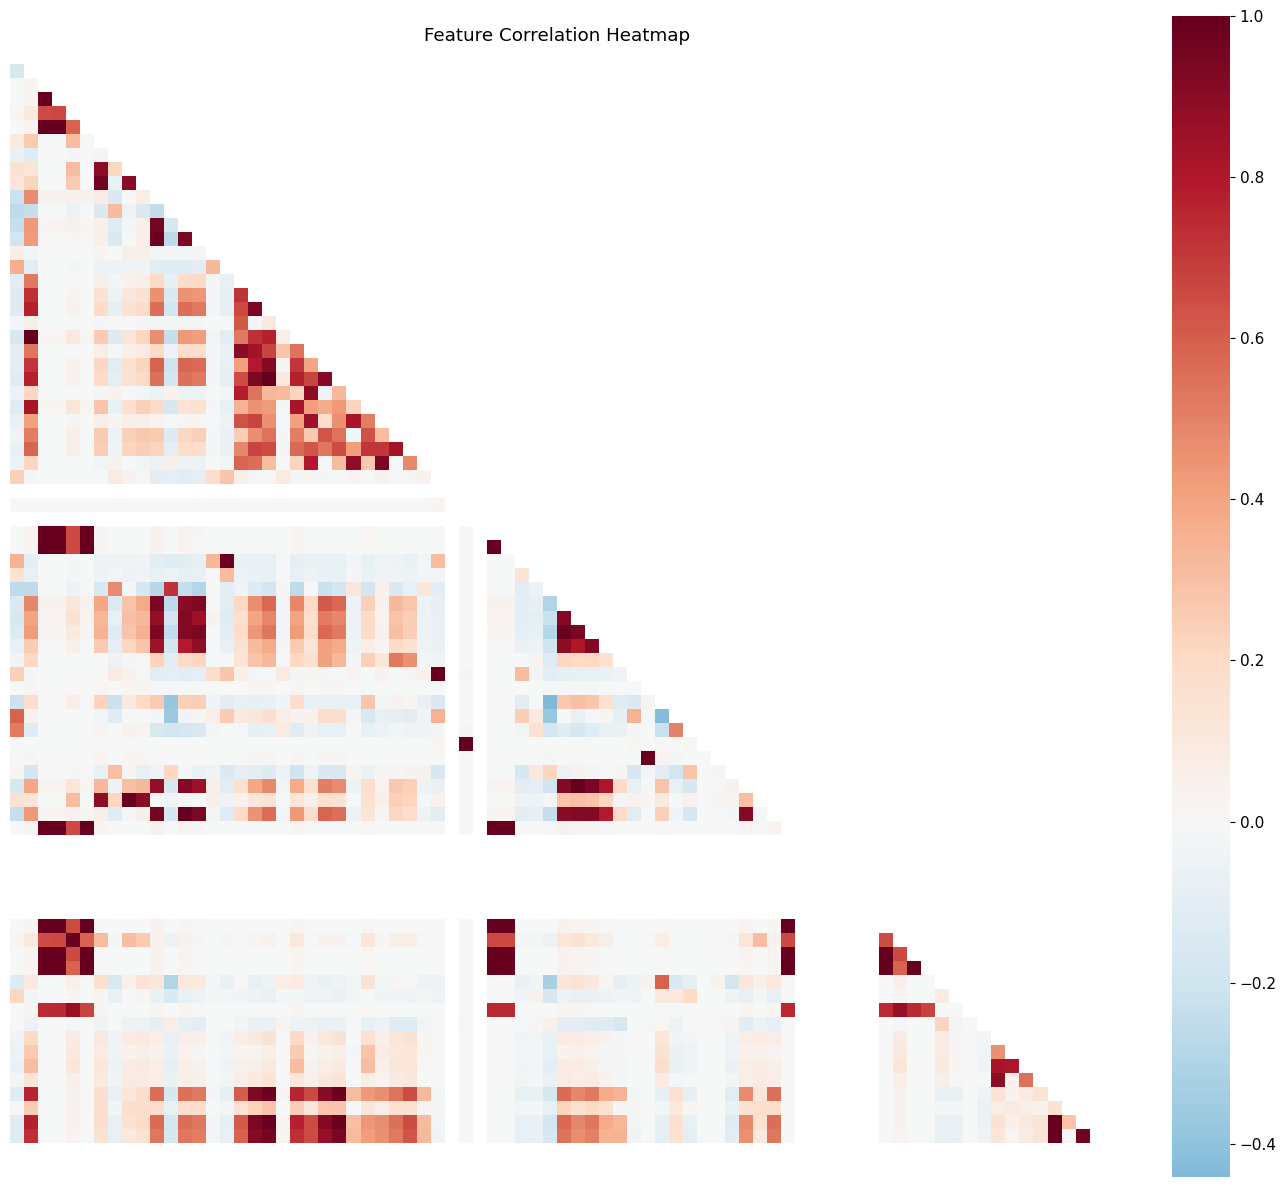

In [5]:
# Correlation Heatmap (Sampled for speed)
corr_sample = df_clean.select_dtypes(include=[np.number]).sample(min(50000, len(df_clean)), random_state=RANDOM_SEED)
corr = corr_sample.corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, square=True, xticklabels=False, yticklabels=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'correlation_heatmap.png'))
plt.show()

## 4. Label Encoding & Stratified Sampling

In [6]:
labels = df_clean['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
features = df_clean.drop(columns=['Label']).select_dtypes(include=[np.number])

print(f'Taking stratified sample of {SAMPLE_SIZE:,} rows for manageable runtimes...')
combined = pd.concat([features, labels.rename('target')], axis=1)
sampled = combined.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED, weights=None).reset_index(drop=True)

X = sampled.drop(columns=['target']).values
y = sampled['target'].values
feature_names = features.columns.tolist()
print(f'Sample shape: X={X.shape}, y={y.shape}')

Taking stratified sample of 100,000 rows for manageable runtimes...


Sample shape: X=(100000, 78), y=(100000,)


## 5. Train/Test Split & Normalization

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Data split & normalized.')

Data split & normalized.


## 6. Save Cleaned Data

In [8]:
cleaned_data = {
    'X_train': X_train_scaled, 'X_test': X_test_scaled,
    'y_train': y_train, 'y_test': y_test,
    'feature_names': feature_names, 'scaler': scaler,
    'sample_size': SAMPLE_SIZE
}
with open(os.path.join(RESULTS_DIR, 'preprocessed_data.pkl'), 'wb') as f:
    pickle.dump(cleaned_data, f)
print('✅ Preprocessed data saved successfully!\nProceed to Notebook 02_baseline_model.ipynb.')

✅ Preprocessed data saved successfully!
Proceed to Notebook 02_baseline_model.ipynb.
